## Import Libraries

In [2]:
# Import library yang dibutuhkan
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
# from yellowbrick.cluster import KElbowVisualizer
import joblib

## Load Data

In [3]:
# Memuat dataset dari Kaggle
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "akmaldwiputra/student-lifestyle-dataset",
    "student_lifestyle_dataset.csv"
)

df.head()


/var/folders/sz/1chgmmc55xxbjy3r6mf029km0000gp/T/ipykernel_46676/3235232313.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


### Insight: 
Dataset **Student Lifestyle** berisi informasi tentang gaya hidup mahasiswa dengan 8 kolom:
- **Student_ID**: Identitas unik mahasiswa
- **Study_Hours_Per_Day**: Jam belajar per hari
- **Extracurricular_Hours_Per_Day**: Jam kegiatan ekstrakurikuler
- **Sleep_Hours_Per_Day**: Jam tidur per hari
- **Social_Hours_Per_Day**: Jam bersosialisasi
- **Physical_Activity_Hours_Per_Day**: Jam aktivitas fisik
- **GPA**: Nilai rata-rata (Grade Point Average)
- **Stress_Level**: Tingkat stress (Low, Moderate, High)

## Exploratory Data Analysis (EDA)

In [4]:
# Menampilkan informasi dasar tentang dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


### Insight:
- **Total data**: 2000 mahasiswa
- **7 kolom numerik**: Study_Hours, Extracurricular_Hours, Sleep_Hours, Social_Hours, Physical_Activity_Hours, GPA, Student_ID
- **1 kolom kategorikal**: Stress_Level

In [5]:
# Menampilkan jumlah nilai yang hilang di setiap kolom
print(df.isnull().sum())


Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64


### Insight:
Tidak ada data yang hilang di semua kolom, dataset memiliki kualitas data yang baik dan tidak memerlukan imputasi.

In [6]:

# Menampilkan jumlah data duplikat
print("Jumlah duplikat:", df.duplicated().sum())


Jumlah duplikat: 0


### Insight:
Tidak ada data duplikat, setiap record mahasiswa adalah unik dan tidak ada pengulangan data.

In [7]:
# Menampilkan ringkasan statistik untuk kolom numerik
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,1000.50000,577.494589,1.00,500.75,1000.50,1500.25,2000.0
Study_Hours_Per_Day,2000.0,7.47580,1.423888,5.00,6.30,7.40,8.70,10.0
Extracurricular_Hours_Per_Day,2000.0,1.99010,1.155855,0.00,1.00,2.00,3.00,4.0
Sleep_Hours_Per_Day,2000.0,7.50125,1.460949,5.00,6.20,7.50,8.80,10.0
Social_Hours_Per_Day,2000.0,2.70455,1.688514,0.00,1.20,2.60,4.10,6.0
Physical_Activity_Hours_Per_Day,2000.0,4.32830,2.514110,0.00,2.40,4.10,6.10,13.0
GPA,2000.0,3.11596,0.298674,2.24,2.90,3.11,3.33,4.0


In [8]:
# Menampilkan ringkasan statistik untuk kolom kategorikal
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
display(df[categorical_cols].describe().T)

,count,unique,top,freq
Stress_Level,2000,3,High,1029


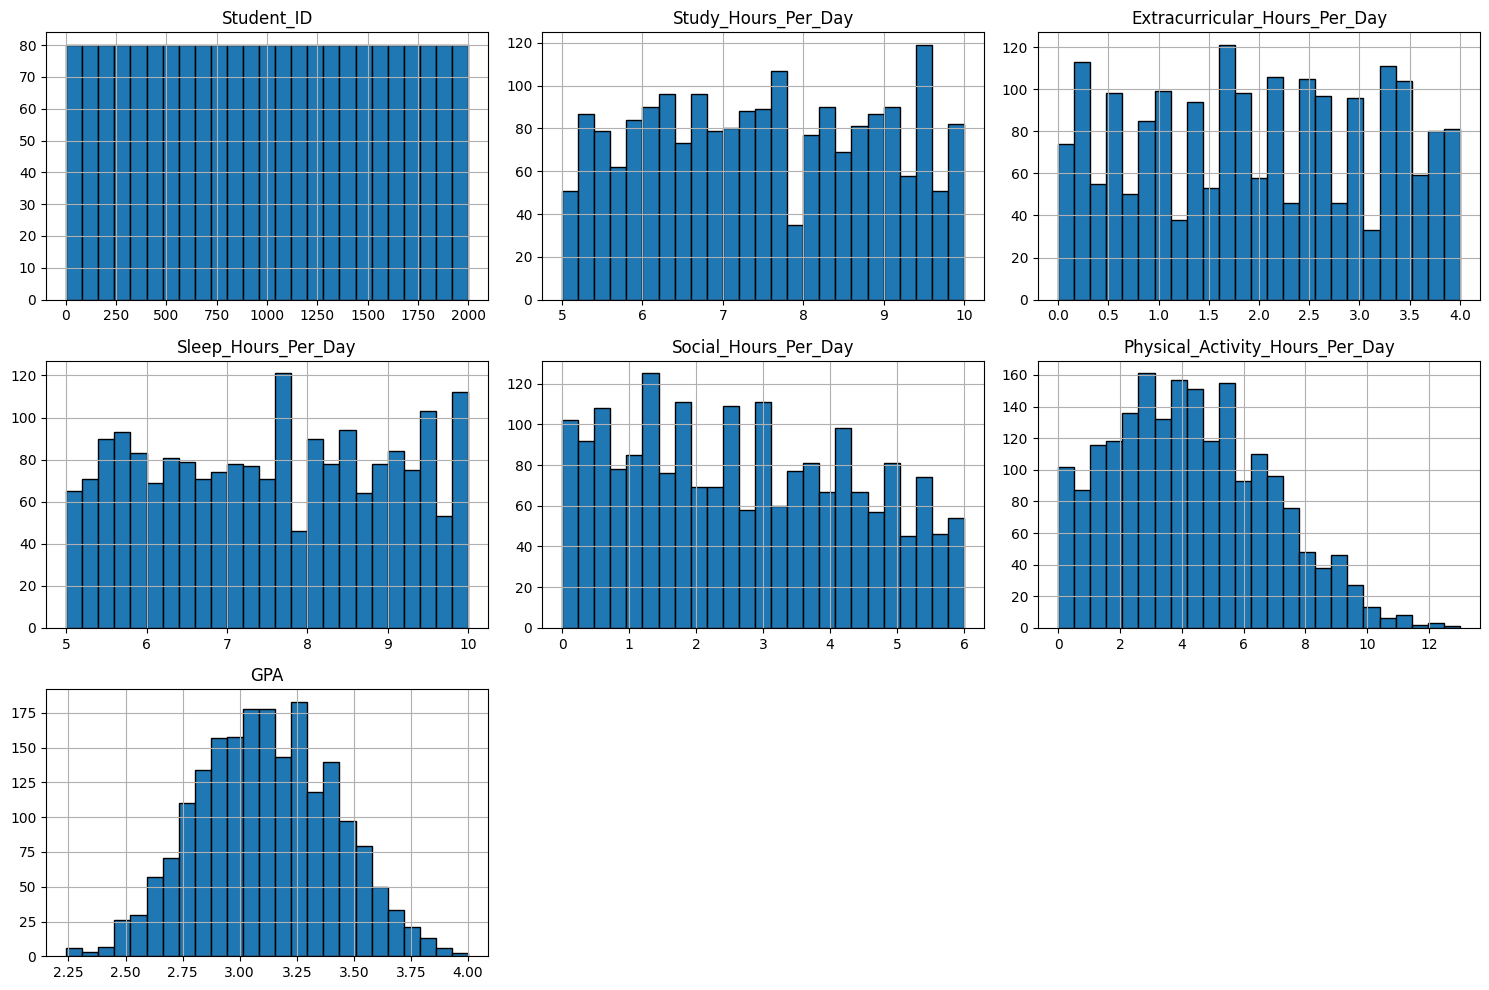

In [14]:
# Visualisasi distribusi fitur numerik
numerical_cols = df.select_dtypes(include=['number']).columns
df[numerical_cols].hist(figsize=(15, 10), bins=25, edgecolor='black')
plt.tight_layout()
plt.show()

### Insight: 

- Tidak ada fitur yang memiliki distribusi sangat skewed
- Sebagian besar fitur memiliki variasi yang baik untuk analisis clustering

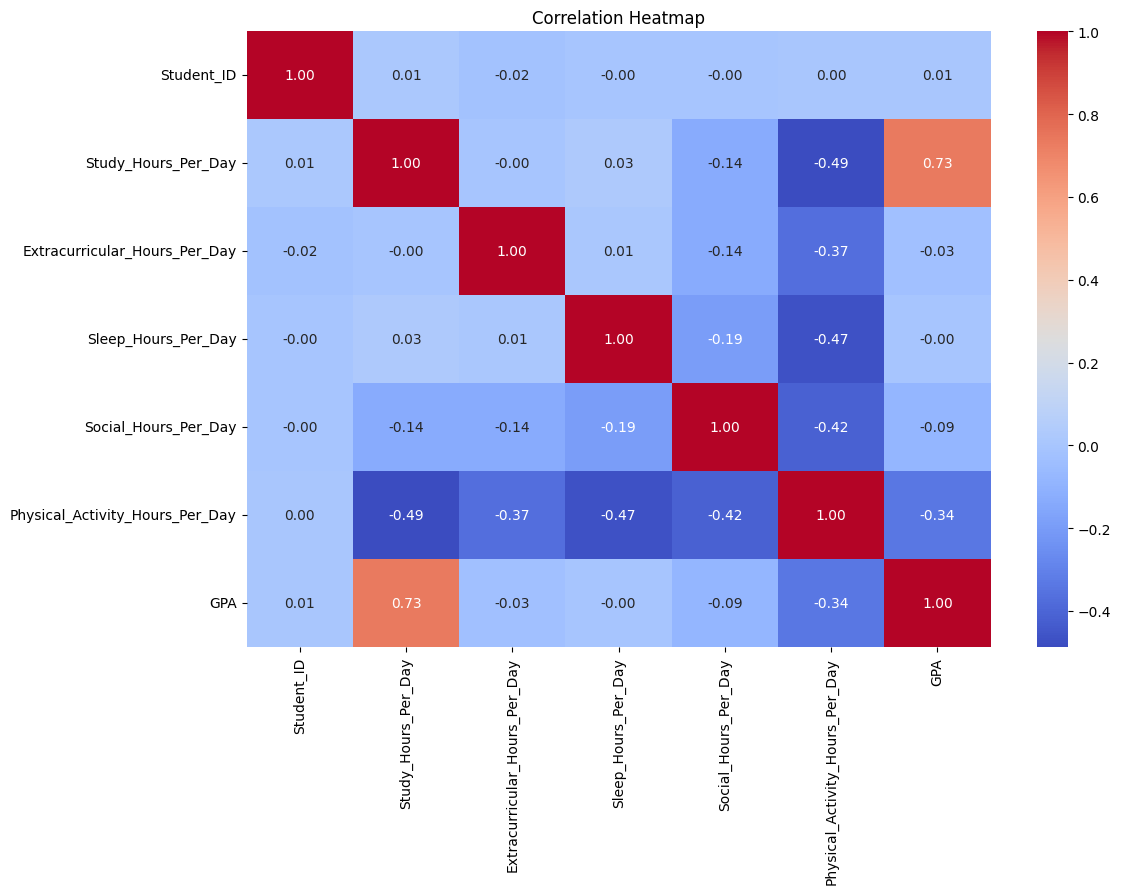

In [10]:
# Menampilkan korelasi antar fitur numerik
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight: 
- Perlu keseimbangan antara belajar, tidur, dan aktivitas fisik
- Mahasiswa perlu manajemen waktu yang lebih baik

**Korelasi Positif :**
- **Study_Hours ↔ GPA**: Semakin banyak belajar, GPA cenderung lebih tinggi

**Korelasi Negatif:**
- **Sleep_Hours ↔ Study_Hours**: Trade-off antara jam belajar dan tidur
- **Physical_Activity ↔ Study_Hours**: Mahasiswa yang banyak belajar cenderung kurang aktivitas fisik


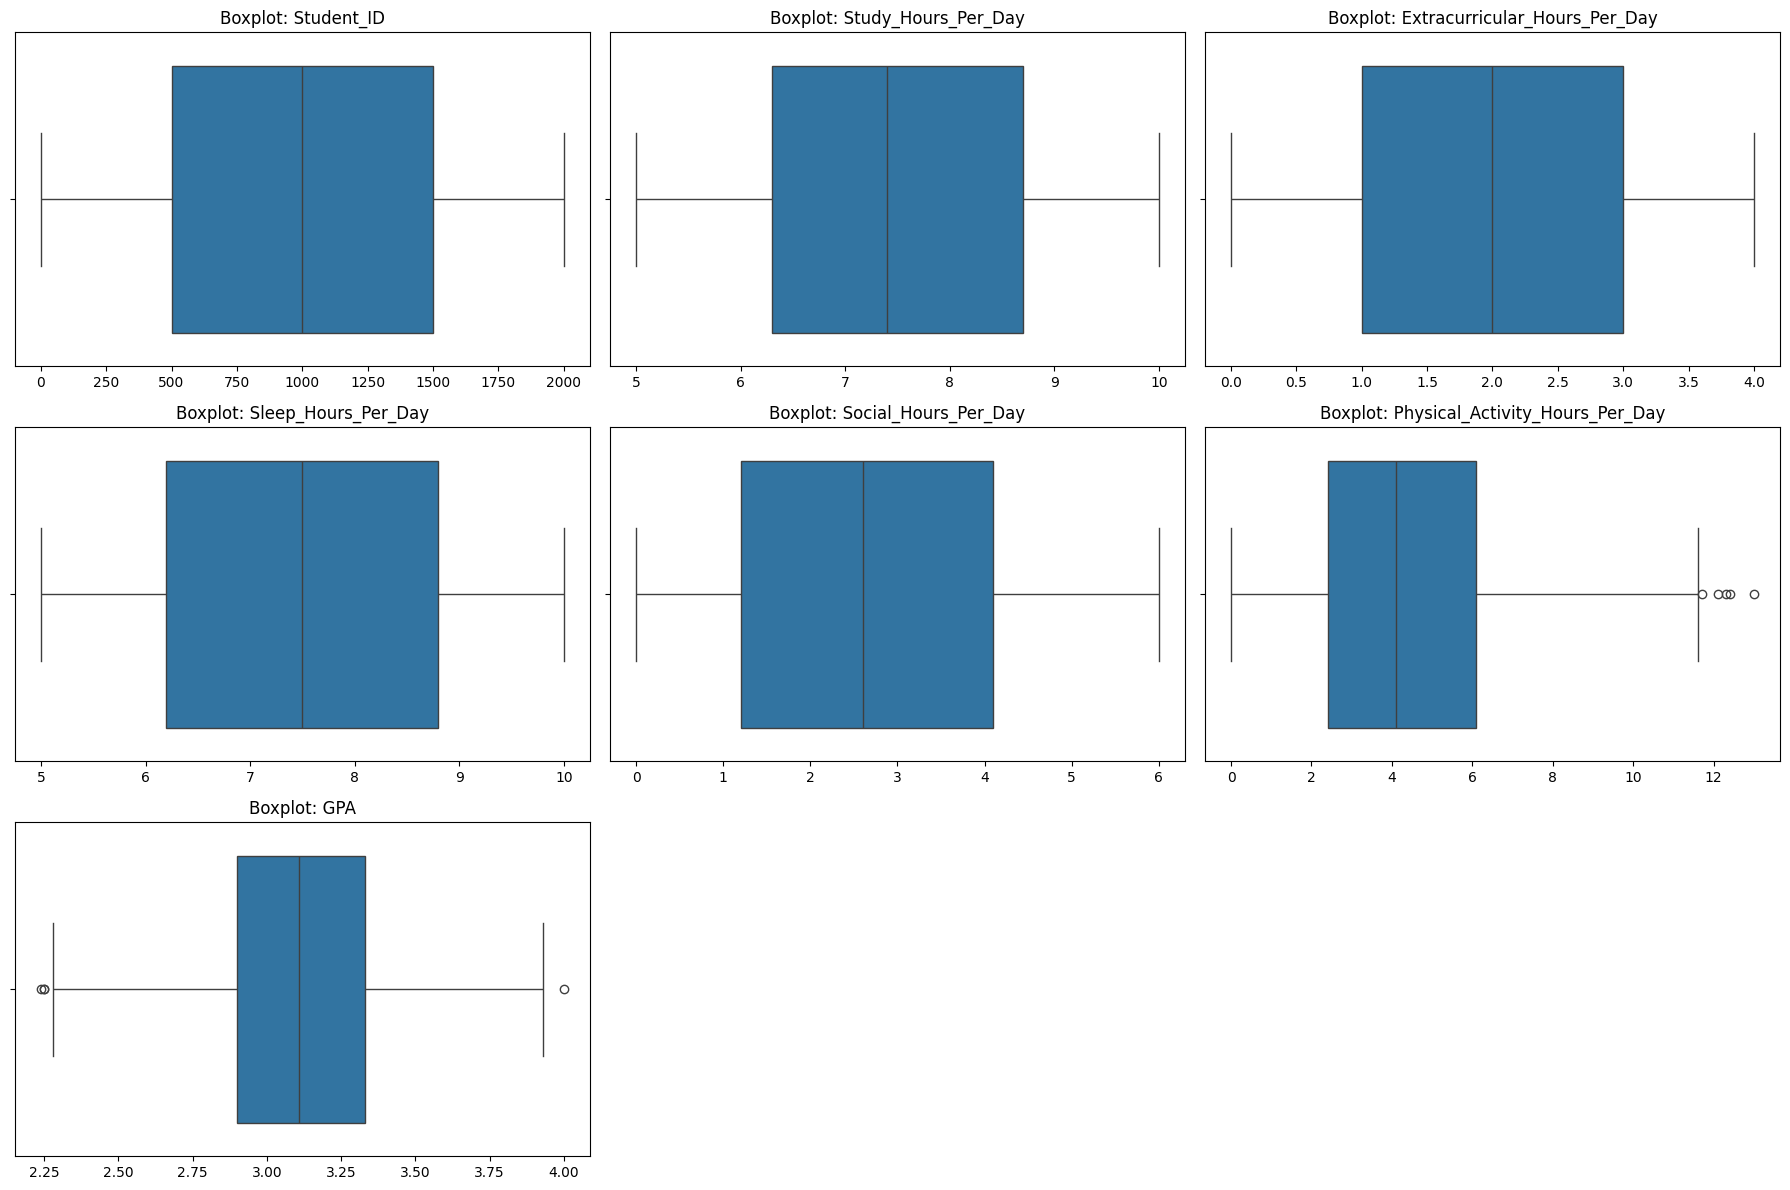

In [22]:
# Mengidentifikasi data outlier dengan boxplot
num_cols = len(numerical_cols)
num_rows = (num_cols + 2) // 3  

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()  

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_xlabel(f'')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Insight:

- Outliers pada Physical_Activity masih masuk akal (atlet bisa latihan 10+ jam)
- Tidak perlu removal outliers, tetap dipertahankan untuk analisis clustering
- Outliers bisa membentuk cluster tersendiri yang menarik untuk dianalisis